In [1]:
from datasets import load_dataset

In [2]:
mnist = load_dataset("ylecun/mnist")

In [3]:
mnist

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 60000
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 10000
    })
})

In [4]:
mnist["train"]["image"][1]

In [5]:
from genaibook.core import show_images

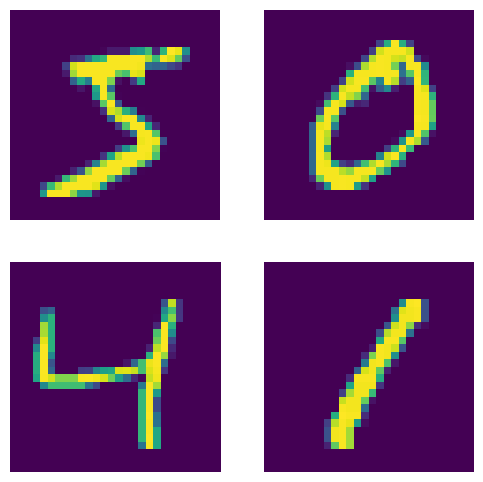

In [6]:
show_images(mnist["train"]["image"][:4])

In [7]:
import matplotlib as mpl

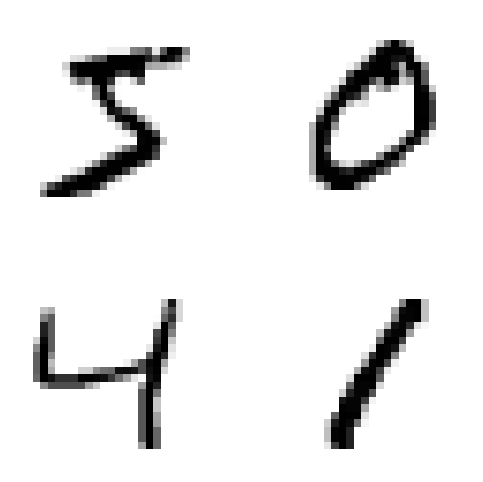

In [8]:
mpl.rcParams["image.cmap"] = "gray_r"
show_images(mnist["train"]["image"][:4])

In [9]:
from torchvision import transforms

In [10]:
def mnist_to_tensor(samples):
    t = transforms.ToTensor()
    samples["image"] = [t(image) for image in samples["image"]]
    return samples

In [11]:
mnist = mnist.with_transform(mnist_to_tensor)
mnist["train"] = mnist["train"].shuffle(seed=1337)

In [12]:
x = mnist["train"]["image"][0]
x.min()

tensor(0.)

In [13]:
x.max()

tensor(1.)

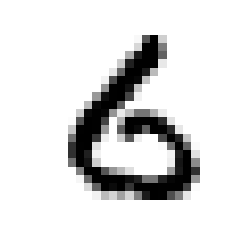

In [14]:
show_images(mnist["train"]["image"][0])

In [15]:
from torch.utils.data import DataLoader

In [16]:
bs=64
train_dataloader = DataLoader(mnist["train"]["image"],batch_size=bs)

In [17]:
from torch import nn

def conv_block(in_channels, out_channels, kernel_size=4, stride=2, padding=1):
    return nn.Sequential(
        nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding
        ),
        nn.BatchNorm2d(out_channels),
        nn.ReLU()
    )

class Encoder(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.conv1 = conv_block(in_channels, 128)
        self.conv2 = conv_block(128,256)
        self.conv3 = conv_block(256,512)
        self.conv4 = conv_block(512,1024)
        self.linear = nn.Linear(1024,16)

    def forward(self,x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)

        x = self.linear(x.flatten(start_dim=1))
        return x

In [18]:
mnist["train"]["image"][0].shape

torch.Size([1, 28, 28])

In [19]:
in_channels = 1

x=mnist["train"]["image"][0][None, :]
encoder = Encoder(in_channels).eval()

encoded = encoder(x)
encoded.shape

torch.Size([1, 16])

In [20]:
def conv_transpose_block(
    in_channels,
    out_channels,
    kernel_size=3,
    stride=2,
    padding=1,
    output_padding=0,
    with_act = True
):
    modules = [
        nn.ConvTranspose2d(
            in_channels,
            out_channels,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding,
            output_padding = output_padding
        )
    ]
    if with_act:
        modules.append(nn.BatchNorm2d(out_channels))
        modules.append(nn.ReLU())
    return nn.Sequential(*modules)

class Decoder(nn.Module):
    def __init__(self, out_channels):
        super().__init__()

        self.linear = nn.Linear(16,1024*4*4)
        self.t_conv1 = conv_transpose_block(1024,512)
        self.t_conv2 = conv_transpose_block(512,256,output_padding=1)
        self.t_conv3 = conv_transpose_block(256,out_channels, output_padding=1)

    def forward(self,x):
        bs = x.shape[0]
        x= self.linear(x) #(bs, 1024*4*4)
        x= x.reshape((bs,1024,4,4)) #(bs,1024,4,4)
        x= self.t_conv1(x) #(bs, 512, 7, 7)
        x= self.t_conv2(x) #(bs, 256, 14, 14)
        x= self.t_conv3(x) #(bs, 1, 28, 28)
        return x
        


In [21]:
# 1. Tanımladığınız DataLoader'dan 64 resimlik İLK PAKETİ çekiyoruz
batch = next(iter(train_dataloader)) 
print("Batch boyutu:", batch.shape) # Çıktı: [64, 1, 28, 28] olmalı

# 2. Bu 64 resmi Encoder'dan geçirip sıkıştırıyoruz
encoded_batch = encoder(batch)
print("Sıkıştırılmış boyut:", encoded_batch.shape) # Çıktı: [64, 16] olmalı

# 3. Decoder'ı doğru şekilde (kanal sayısı 1 olacak şekilde) tanımlıyoruz
decoder_model = Decoder(out_channels=1)

# 4. Sıkıştırılmış 64'lük veriyi Decoder'a verip orijinal boyuta geri açıyoruz
decoded_batch = decoder_model(encoded_batch)
print("Sonuç (Decoder) boyutu:", decoded_batch.shape) # Çıktı: [64, 1, 28, 28] olacak!

Batch boyutu: torch.Size([64, 1, 28, 28])
Sıkıştırılmış boyut: torch.Size([64, 16])
Sonuç (Decoder) boyutu: torch.Size([64, 1, 28, 28])


In [22]:
class AutoEncoder(nn.Module):
    def __init__(self,in_channels):
        super().__init__()
        self.encoder = Encoder(in_channels)
        self.decoder = Decoder(in_channels)

    def encode(self, x):
        return self.encoder(x)

    def decode(self, x):
        return self.decoder(x)

    def forward(self,x):
        return self.decode(self.encode(x))

In [23]:
model = AutoEncoder(1)

In [24]:
import torchsummary 

torchsummary.summary(model,input_size=(1,28,28),device="cpu")

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 128, 14, 14]           2,176
       BatchNorm2d-2          [-1, 128, 14, 14]             256
              ReLU-3          [-1, 128, 14, 14]               0
            Conv2d-4            [-1, 256, 7, 7]         524,544
       BatchNorm2d-5            [-1, 256, 7, 7]             512
              ReLU-6            [-1, 256, 7, 7]               0
            Conv2d-7            [-1, 512, 3, 3]       2,097,664
       BatchNorm2d-8            [-1, 512, 3, 3]           1,024
              ReLU-9            [-1, 512, 3, 3]               0
           Conv2d-10           [-1, 1024, 1, 1]       8,389,632
      BatchNorm2d-11           [-1, 1024, 1, 1]           2,048
             ReLU-12           [-1, 1024, 1, 1]               0
           Linear-13                   [-1, 16]          16,400
          Encoder-14                   

In [25]:
import torch
from matplotlib import pyplot as plt
from torch.nn import functional as F
from tqdm.notebook import tqdm, trange

from genaibook.core import get_device

num_epochs = 10
lr = 1e-4
device = get_device()
model = model.to(device)
optimizer = torch.optim.AdamW(model.parameters(),lr=lr,eps=1e-5)

losses = []
for _ in (progress := trange(num_epochs, desc="Training")):
    for _, batch in (
        inner := tqdm(enumerate(train_dataloader), total=len(train_dataloader))
    ):
        batch = batch.to(device)
        
        # Pass through the model and obtain reconstructed images
        preds = model(batch)
        
        # Compare the prediction with the original images
        loss = F.mse_loss(preds, batch)
        
        # Display loss and store for plotting
        inner.set_postfix(loss=f"{loss.cpu().item():.3f}")
        losses.append(loss.item())
        
        # Update the model parameters with the optimizer based on this loss
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
progress.set_postfix(loss=f"{loss.cpu().item():.3f}", lr=f"{lr:.0e}")

Training:   0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

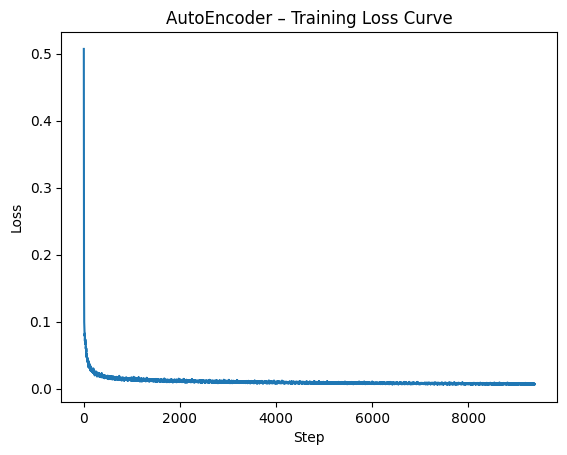

In [26]:
plt.plot(losses)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("AutoEncoder – Training Loss Curve")
plt.show()

In [27]:
eval_bs = 16
eval_dataloader = DataLoader(mnist["test"]["image"],  batch_size=eval_bs)

model.eval()
with torch.inference_mode():
    eval_batch = next(iter(eval_dataloader))
    predicted = model(eval_batch.to(device)).cpu()

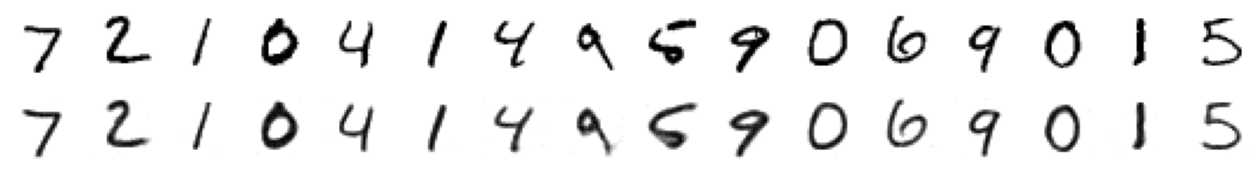

In [28]:
batch_vs_preds = torch.cat((eval_batch, predicted))
show_images(batch_vs_preds,imsize=1,nrows=2)